# Visualize a generated lensed-quasar light curve

This notebook loads an HDF5 file produced by `lightcurve_gen` (via
`python -m lightcurve_gen.cli` or the `run_light_curve_gen.sh` script) and
plots the lensed and microlensed+lensed light curves per image and band.

Every light curve plot in this notebook:
- shows photometric error bars on every point,
- shades any gap in observations longer than ~4 months as a "season gap"
  (common for real survey cadences like Rubin's, where the field goes
  behind the sun for part of the year).

It also includes a plot overlaying the user-defined telescope's cadence
against the Rubin cadence (if you generated both), and a plot of the
photometric error distribution per band for each cadence.

This notebook does **not** run the generator itself — AMOEBA/IPM/Rubin
simulation is heavy and belongs in a script/job, not a notebook. Point
`H5_PATH` below at an already-generated `.h5` file.

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Path to a light curve file produced by lightcurve_gen.cli / run_light_curve_gen.sh
H5_PATH = "../outputs/custom_telescope/09062026/example_run2.h5"


## Inspect what's in the file

In [15]:
def get_band_names(h5_path):
    with h5py.File(h5_path, "r") as f:
        return [b.decode() if isinstance(b, bytes) else b for b in f["metadata"]["band_names"][:]]


with h5py.File(H5_PATH, "r") as f:
    band_names = get_band_names(H5_PATH)
    num_images = int(f["metadata"]["num_images"][()])
    cadence_groups = [k for k in f.keys() if k.endswith("_cadence")]

print("Bands:", band_names)
print("Number of lensed images:", num_images)
print("Cadence groups present:", cadence_groups)


Bands: ['u', 'g', 'r']
Number of lensed images: 2
Cadence groups present: ['rubin_cadence', 'user_cadence']


## Shared helpers

`shade_season_gaps` marks any break longer than `min_gap_days` (default
~4 months = 120 days) with a shaded band, so a real gap in survey
coverage doesn't get mistaken for a smooth part of the light curve. It
accepts one or more time arrays — pass every cadence/band you're plotting
on a given axis so a "gap" only shows where *none* of them have data.

In [16]:
def find_season_gaps(*time_arrays, min_gap_days=120):
    """Return [(gap_start, gap_end), ...] for any break longer than min_gap_days,
    across the union of all the time arrays passed in."""
    all_times = np.concatenate([np.asarray(t) for t in time_arrays if len(t) > 0])
    if len(all_times) < 2:
        return []
    all_times = np.sort(np.unique(all_times))
    diffs = np.diff(all_times)
    gap_idx = np.where(diffs > min_gap_days)[0]
    return [(all_times[i], all_times[i + 1]) for i in gap_idx]


def shade_season_gaps(ax, *time_arrays, min_gap_days=120, color="0.85"):
    gaps = find_season_gaps(*time_arrays, min_gap_days=min_gap_days)
    for i, (start, end) in enumerate(gaps):
        ax.axvspan(start, end, color=color, zorder=0, label=("season gap" if i == 0 else None))
    return gaps


## Plot one image, all bands

Shows the lensed (macro-magnified, no microlensing) magnitudes with their
photometric error bars, for a single lensed image, across every band.

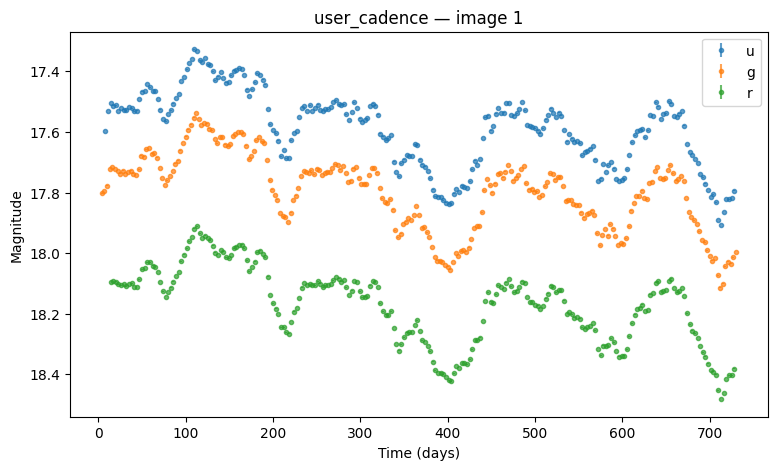

In [17]:
def plot_image_all_bands(h5_path, cadence_group, image_index=1, ax=None, min_gap_days=120):
    """image_index is 1-based, matching the 'image_1', 'image_2', ... groups."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    band_names = get_band_names(h5_path)
    all_times = []
    with h5py.File(h5_path, "r") as f:
        img_grp = f[cadence_group]["lensed_mags"][f"image_{image_index}"]
        times = f[cadence_group]["observation_dates"][f"image_times_{image_index}"]

        for band in band_names:
            if band not in img_grp:
                continue
            mags = img_grp[band][:]
            errs = img_grp[f"{band}_err"][:]
            t = times[band][:] if band in times else np.arange(len(mags))
            all_times.append(t)
            ax.errorbar(t, mags, yerr=errs, fmt="o", markersize=3, alpha=0.7, label=band)

    shade_season_gaps(ax, *all_times, min_gap_days=min_gap_days)
    ax.invert_yaxis()  # brighter (lower mag) at the top
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{cadence_group} — image {image_index}")
    ax.legend()
    return ax


plot_image_all_bands(H5_PATH, cadence_group="user_cadence", image_index=1)
plt.show()


## Compare lensed-only vs microlensed+lensed, one band

Shows how microlensing adds scatter on top of the macro-lensed light curve
for a single band, for one image.

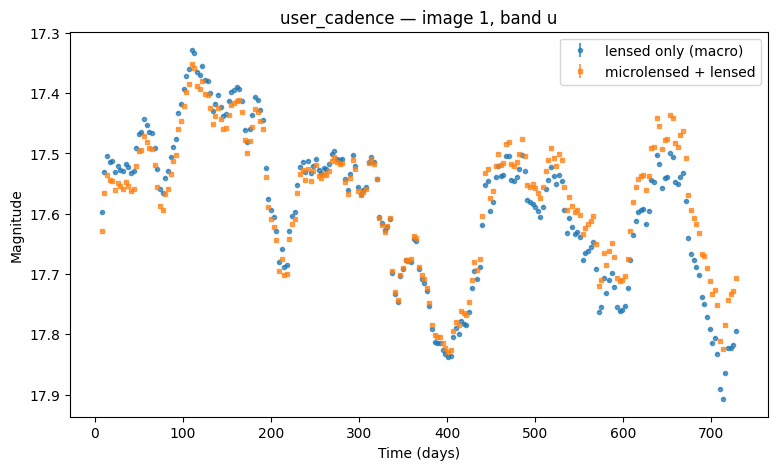

In [18]:
def plot_lensed_vs_microlensed(h5_path, cadence_group, band, image_index=1, ax=None, min_gap_days=120):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    with h5py.File(h5_path, "r") as f:
        lensed_grp = f[cadence_group]["lensed_mags"][f"image_{image_index}"]
        ml_grp = f[cadence_group]["microlensed_and_lensed_mags"][f"image_mags_{image_index}"]
        times = f[cadence_group]["observation_dates"][f"image_times_{image_index}"]

        t = times[band][:]
        lensed_mags = lensed_grp[band][:]
        lensed_errs = lensed_grp[f"{band}_err"][:]
        ml_mags = ml_grp[band][:]
        ml_errs = ml_grp[f"{band}_err"][:]

    ax.errorbar(t, lensed_mags, yerr=lensed_errs, fmt="o", markersize=3,
                alpha=0.7, label="lensed only (macro)")
    ax.errorbar(t, ml_mags, yerr=ml_errs, fmt="s", markersize=3,
                alpha=0.7, label="microlensed + lensed")
    shade_season_gaps(ax, t, min_gap_days=min_gap_days)
    ax.invert_yaxis()
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{cadence_group} — image {image_index}, band {band}")
    ax.legend()
    return ax


band_names = get_band_names(H5_PATH)
plot_lensed_vs_microlensed(H5_PATH, cadence_group="user_cadence", band=band_names[0], image_index=1)
plt.show()


## All images, one band, in a grid

Useful for a quick look at every lensed image side by side.

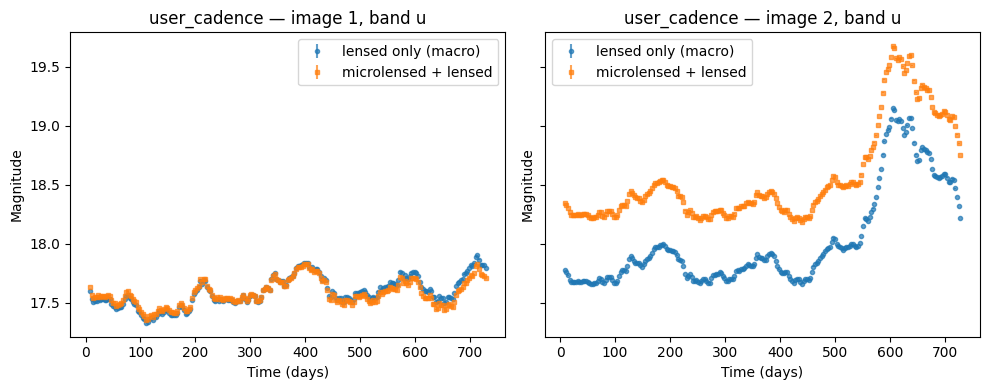

In [19]:
def plot_all_images_one_band(h5_path, cadence_group, band, min_gap_days=120):
    with h5py.File(h5_path, "r") as f:
        num_images = int(f["metadata"]["num_images"][()])

    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 4), sharey=True)
    if num_images == 1:
        axes = [axes]

    for image_index in range(1, num_images + 1):
        plot_lensed_vs_microlensed(h5_path, cadence_group, band, image_index=image_index,
                                    ax=axes[image_index - 1], min_gap_days=min_gap_days)

    fig.tight_layout()
    return fig


plot_all_images_one_band(H5_PATH, cadence_group="user_cadence", band=band_names[0])
plt.show()


## If a Rubin cadence was also generated (`--include_rubin` or `--rubin_only`)

Same plotting functions work — just pass `cadence_group="rubin_cadence"`.
Real survey cadences like Rubin's usually have genuine season gaps, so
this is where the shading is most likely to actually show up.

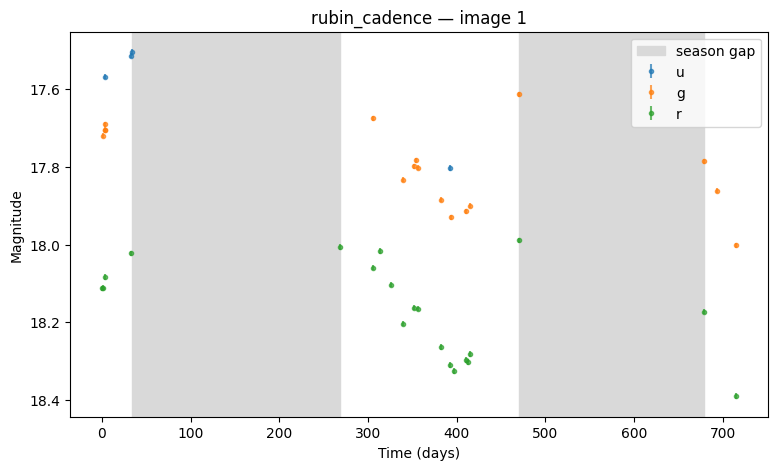

In [20]:
with h5py.File(H5_PATH, "r") as f:
    has_rubin = "rubin_cadence" in f
    has_user = "user_cadence" in f

if has_rubin:
    plot_image_all_bands(H5_PATH, cadence_group="rubin_cadence", image_index=1)
    plt.show()
else:
    print("No rubin_cadence group in this file (generated without --include_rubin/--rubin_only).")


## User-defined telescope vs Rubin, overlaid

Only runs if the file has *both* a `user_cadence` and a `rubin_cadence`
group (i.e. it was generated with `--include_rubin`, not `--rubin_only`).
Both curves are the same underlying AGN variability and microlensing
realization — this shows how differently your telescope's cadence and
Rubin's actually sample it.

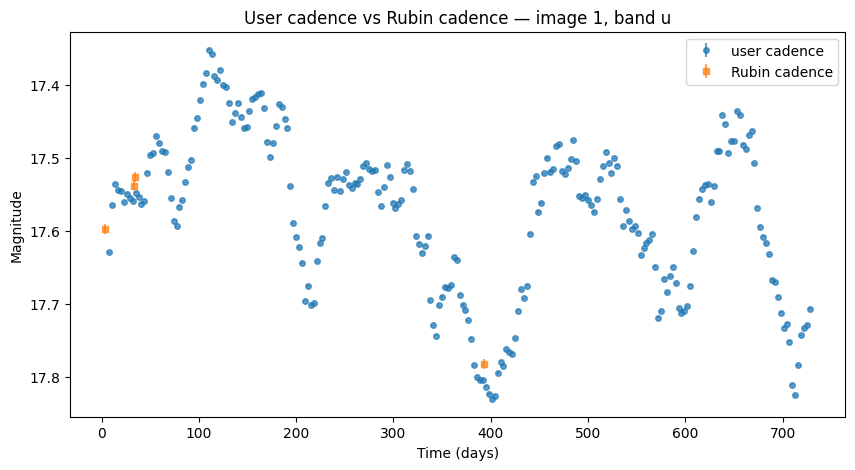

In [21]:
def plot_user_vs_rubin(h5_path, band, image_index=1, mag_group="microlensed_and_lensed_mags",
                        ax=None, min_gap_days=120):
    with h5py.File(h5_path, "r") as f:
        if not ("user_cadence" in f and "rubin_cadence" in f):
            print("Need both user_cadence and rubin_cadence in the file to overlay them.")
            return None

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    group_key = "lensed_mags" if mag_group == "lensed_mags" else "microlensed_and_lensed_mags"
    img_key = f"image_{image_index}" if group_key == "lensed_mags" else f"image_mags_{image_index}"

    all_times = []
    with h5py.File(h5_path, "r") as f:
        for cadence_group, style in [
            ("user_cadence", dict(fmt="o", label="user cadence")),
            ("rubin_cadence", dict(fmt="s", label="Rubin cadence")),
        ]:
            grp = f[cadence_group][group_key][img_key]
            times = f[cadence_group]["observation_dates"][f"image_times_{image_index}"]
            t = times[band][:]
            mags = grp[band][:]
            errs = grp[f"{band}_err"][:]
            all_times.append(t)
            ax.errorbar(t, mags, yerr=errs, markersize=4, alpha=0.7, **style)

    shade_season_gaps(ax, *all_times, min_gap_days=min_gap_days)
    ax.invert_yaxis()
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"User cadence vs Rubin cadence — image {image_index}, band {band}")
    ax.legend()
    return ax


if has_user and has_rubin:
    plot_user_vs_rubin(H5_PATH, band=band_names[0], image_index=1)
    plt.show()
else:
    print("This file doesn't have both cadences (needs --include_rubin, not --rubin_only, to have both).")


## Photometric error distributions, per band

Histogram (with a KDE fit) of the photometric error values recorded for
each band, separately for the user-defined telescope and Rubin (whichever
are present in the file). Uses the `microlensed_and_lensed_mags` errors —
the final observed light curve's errors — pooled across every lensed
image in the file.

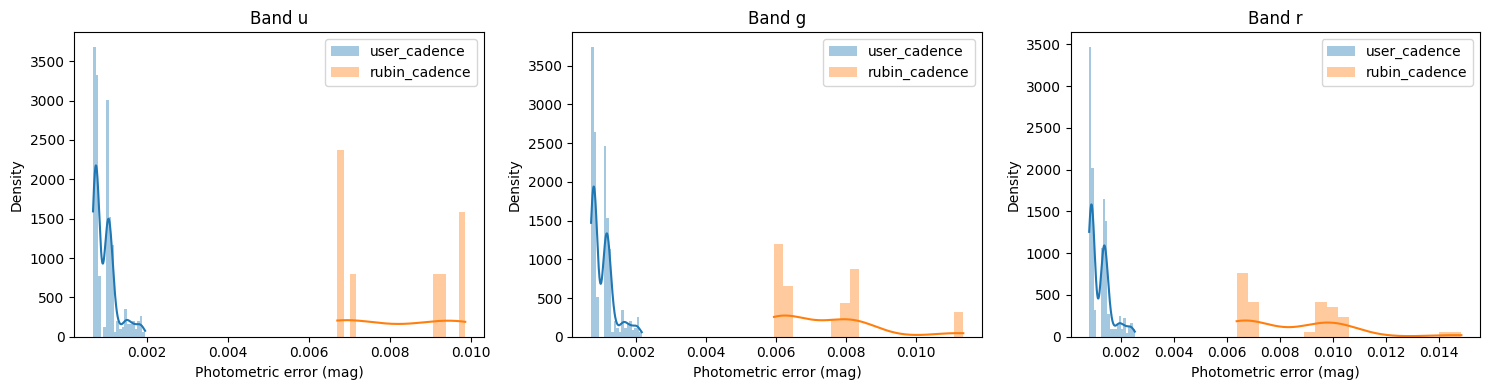

In [22]:
def gather_band_errors(h5_path, cadence_group, band, mag_group="microlensed_and_lensed_mags"):
    """Pool this band's photometric errors across every image in the file."""
    errs = []
    with h5py.File(h5_path, "r") as f:
        if cadence_group not in f:
            return np.array([])
        group_key = "lensed_mags" if mag_group == "lensed_mags" else "microlensed_and_lensed_mags"
        grp = f[cadence_group][group_key]
        for img_key in grp.keys():
            img_grp = grp[img_key]
            err_key = f"{band}_err"
            if err_key in img_grp:
                errs.append(img_grp[err_key][:])
    return np.concatenate(errs) if errs else np.array([])


def plot_error_distributions(h5_path, mag_group="microlensed_and_lensed_mags", bins=20):
    band_names = get_band_names(h5_path)
    with h5py.File(h5_path, "r") as f:
        cadence_groups = [g for g in ["user_cadence", "rubin_cadence"] if g in f]

    colors = {"user_cadence": "tab:blue", "rubin_cadence": "tab:orange"}
    fig, axes = plt.subplots(1, len(band_names), figsize=(5 * len(band_names), 4))
    if len(band_names) == 1:
        axes = [axes]

    for ax, band in zip(axes, band_names):
        for cadence_group in cadence_groups:
            errs = gather_band_errors(h5_path, cadence_group, band, mag_group=mag_group)
            if len(errs) == 0:
                continue
            ax.hist(errs, bins=bins, density=True, alpha=0.4,
                    color=colors.get(cadence_group), label=cadence_group)
            if len(errs) > 1 and np.std(errs) > 0:
                kde = gaussian_kde(errs)
                x_grid = np.linspace(errs.min(), errs.max(), 200)
                ax.plot(x_grid, kde(x_grid), color=colors.get(cadence_group))
        ax.set_title(f"Band {band}")
        ax.set_xlabel("Photometric error (mag)")
        ax.set_ylabel("Density")
        ax.legend()

    fig.tight_layout()
    return fig


plot_error_distributions(H5_PATH)
plt.show()
